In [2]:
import CoolProp.CoolProp as cp
import fluids as fl
import numpy as np

In [100]:
#Parámetros del espiral de cobre
do = 5.15e-3 #Diámetro exterior del espiral (m)
di = 6.35e-3 #Diámetro interior del espiral (m)
l = 1 #Longitud del espiral (m)
n = 10 #Número de vueltas del espiral
r_curv = 0.035
A_out = np.pi*do/2*l #Área de la superficie exterior del espiral (m^2)
A_in = np.pi*di/2*l #Área de la superficie interior del espiral

d_shell = 0.08 #Diámetro del shell (m)
l_shell = 0.1 #Longitud del shell (m)

In [98]:
volumen_cobre = np.pi/4*(do**2)*l #Volumen de cobre en el espiral (m^3)
volumen_shell = np.pi/4*(d_shell**2)*l_shell #Volumen del shell (m^3)
vol_libre = volumen_shell - volumen_cobre #Volumen libre en el shell (m^3)
print (vol_libre*1e3)

M = vol_libre * 1000 #Masa de agua en el shell (kg)
cp_water = 4180 #Calor específico del agua (kJ/kg*K)

fraction_water = 0.7
fraction_ethanol = 0.3

# Crear mezcla HEOS
fluid = f"HEOS::Water[{fraction_water}]&Ethanol[{fraction_ethanol}]"

P = 101325   # Presión [Pa] (1 atm)

T_water_in = 20 + 273.15 #Temperatura de entrada del agua (K)
T_refrigerant_in = 1 + 273.15 #Temperatura de entrada del refrigerante (K)

# Propiedades
rho_refrigerant = cp.PropsSI("D", "T", T_refrigerant_in, "P", P, fluid)   # densidad [kg/m³]
cp_refrigerant  = cp.PropsSI("C", "T", T_refrigerant_in, "P", P, fluid)   # calor específico [J/(kg·K)]
mu_refrigerant  = cp.PropsSI("V", "T", T_refrigerant_in, "P", P, fluid)   # viscosidad dinámica [Pa·s]
k_refrigerant   = cp.PropsSI("L", "T", T_refrigerant_in, "P", P, fluid)   # conductividad térmica [W/(m·K)]

k_water = cp.PropsSI("L", "T", T_water_in, "Q", 0, "water")   # conductividad térmica del agua [W/(m·K)]

m_dot_refrigerant = 1.98/1000/60 * 1000 #Flujo másico del refrigerante (kg/s)
m_dot_water = 30/1000**2 * 1000 #Flujo másico del agua (kg/s)

0.48182410178565815


## Parámetros adimensionales

In [106]:
Re_water = (4 * m_dot_water) / (np.pi * d_shell * mu_refrigerant)
Pr_water = cp.PropsSI('Prandtl','T',T_water_in,'Q',0,'water')
De_water = Re_water * np.sqrt(do/2/r_curv)
curv = (di+do)/2/(2*r_curv) #0.05 sería el diámetro del espiral, se debe ajustar según el diseño real del espiral

Pr_wall = cp.PropsSI('Prandtl','T',T_refrigerant_in,'Q',0,fluid)

print(f"Reynolds del agua: {Re_water:.2f}")
print(f"Prandtl del agua: {Pr_water:.2f}")
print(f"Dean del agua: {De_water:.2f}")
print(f"Curvatura del espiral: {curv:.3f}") 

Reynolds del agua: 146.71
Prandtl del agua: 7.01
Dean del agua: 39.79
Curvatura del espiral: 0.082


In [110]:
f = 0.316*Re_water**(-0.2)*curv**0.1

m = 0.5 + 0.2903 * curv**0.194
m_ = 2300 * (1 + 8.6 * curv**0.45) # Para m < m_

Nu_water = 3.74 + 0.064 * curv**0.9 * Re_water**m * Pr_water**(1/3) * (Pr_water/Pr_wall)**0.14

#Nu_water = 0.13*(f*Re_water/2)*Pr_water**(1/3)

h_water = Nu_water * k_water / d_shell
print(f"Coeficiente de transferencia de calor interno por convección del agua: {h_water:.2f} W/m²K")

Coeficiente de transferencia de calor interno por convección del agua: 30.25 W/m²K


In [ ]:
#Parámetros termodinámicos
T_water_in = 20 + 273.15 #Temperatura de entrada del agua (K)
T_refrigerant_in = 1 + 273.15 #Temperatura de entrada del refrigerante (K)

#REVISAR
ho = h_water
R_fi = 0
R_fo = 0
hi = 2000
k_copper = 401 #Conductividad térmica del cobre (W/mK)


U = (do/di/hi + do*np.log(do/di)/k_copper + 1/ho + do/di*R_fi + R_fo)**(-1) #Coeficiente global de transferencia de calor (W/m^2K)

T_water_out = T_water_in
T_water = [[0, T_water_out-273.15]] #Temperatura del agua en el shell (°C)
t = 0
while T_water_out > 12 + 273.15: #Iteramos hasta que el agua alcance los 10°C

    #REVISAR
    c_h = cp.PropsSI('C','T',T_refrigerant_in,'Q',0,'water') #Capacidad calorífica del refrigerante (J/kgK)
    c_c = cp.PropsSI('C','T',T_water_in,'Q',0,'water') #Capacidad calorífica del agua (J/kgK)
    m_dot_refrigerant = 1.98/1000/60 * 1000 #Flujo másico del refrigerante (kg/s)
    m_dot_water = 30/1000**2 * 1000 #Flujo másico del agua (kg/s)
    t_step = l_shell/(4 * m_dot_water / 1000 / d_shell**2 / np.pi) #Tiempo que tarda el agua en llenar el volumen libre del shell (s)
    C_h = m_dot_water * c_h #Capacidad térmica del refrigerante (W/K)
    C_c = m_dot_refrigerant * c_c #Capacidad térmica del agua (W/K)
    C_min = min(C_h, C_c) #Capacidad térmica mínima (W/K)
    C_max = max(C_h, C_c) #Capacidad térmica máxima (W/K)
    C_r = C_min / C_max
    NTU = U * A_out / C_min

    #Efectividad del intercambiador para intercambiador de doble paso y flujo cruzado (caso sobredimensionado):
    epsilon = (1 - np.exp(-NTU * (1 - C_r))) / (1 - C_r * np.exp(-NTU * (1 - C_r)))

    #El calor transferido es:
    Q = epsilon * C_min * (T_water_in - T_refrigerant_in)

    #Con ello calculamos las temperaturas de salida:
    T_water_in = T_water_out
    T_water_out = T_water_out - Q / C_h
    T_refrigerant_out = T_refrigerant_in + Q / C_c 
    
    t += t_step
    T_water.append([t/60, T_water_out-273.15]) #En minutos y °C

T_water_in = 20 + 273.15 #Temperatura de entrada del agua (K)

T_water = np.array(T_water)

print(f"Temperatura de salida del agua: {T_water_out - 273.15:.2f} °C")
print(f"Temperatura de salida del refrigerante: {T_refrigerant_out - 273.15:.2f} °C")

Temperatura de salida del agua: 11.85 °C
Temperatura de salida del refrigerante: 1.48 °C


In [82]:
M = vol_libre * 1000 #Masa de agua en el shell (kg)
cp_water = 4180 #Calor específico del agua (kJ/kg*K)

fraction_water = 0.7
fraction_ethanol = 0.3

# Crear mezcla HEOS
fluid = f"HEOS::Water[{fraction_water}]&Ethanol[{fraction_ethanol}]"

P = 101325   # Presión [Pa] (1 atm)

# Propiedades
rho_refrigerant = cp.PropsSI("D", "T", T_refrigerant_in, "P", P, fluid)   # densidad [kg/m³]
cp_refrigerant  = cp.PropsSI("C", "T", T_refrigerant_in, "P", P, fluid)   # calor específico [J/(kg·K)]
mu_refrigerant  = cp.PropsSI("V", "T", T_refrigerant_in, "P", P, fluid)   # viscosidad dinámica [Pa·s]
k_refrigerant   = cp.PropsSI("L", "T", T_refrigerant_in, "P", P, fluid)   # conductividad térmica [W/(m·K)]

k_water = cp.PropsSI("L", "T", T_water_in, "Q", 0, "water")   # conductividad térmica del agua [W/(m·K)]

$$M\cdot c_{p,water} \cdot \frac{dT}{dt} = -\epsilon \cdot \dot{m} \cdot c_{p,water} \cdot (T(t) - T_{frío})$$

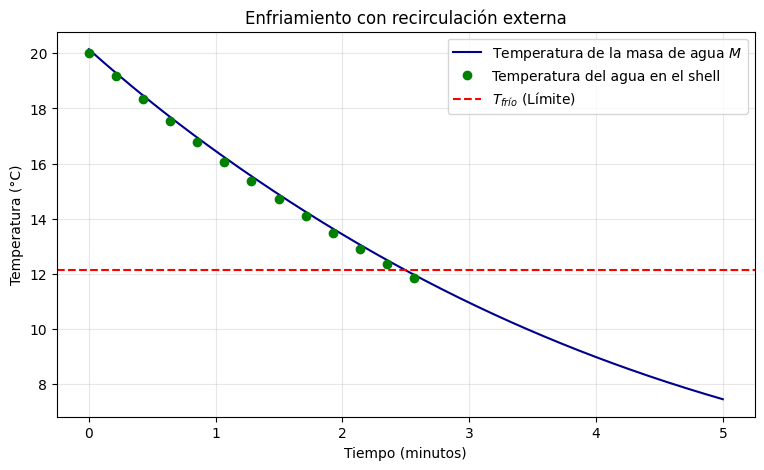

In [83]:
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

def modelo_enfriamiento(t, T, epsilon, m_punto, cpf, M, cpm, T_frio):
    # Ecuación diferencial con calores específicos distintos
    dTdt = -(epsilon * m_punto * cpf) / (M * cpm) * (T - T_frio)
    return dTdt

# --- Simulación ---
T0 = [T_water_in]
t_span = (0, 600)
t_eval = np.linspace(0, 300, 300)

sol = solve_ivp(
    modelo_enfriamiento, 
    t_span, 
    T0, 
    args=(epsilon, m_dot_water, cp_water, M, cp_water, T_refrigerant_in), 
    t_eval=t_eval
)

# --- Gráfica ---
plt.figure(figsize=(9, 5))
plt.plot(sol.t / 60, sol.y[0]-273, color='darkblue', label='Temperatura de la masa de agua $M$')
plt.plot(T_water[:, 0], T_water[:, 1], 'go', label='Temperatura del agua en el shell')
plt.axhline(y=T_refrigerant_in+11-273, color='red', linestyle='--', label='$T_{frío}$ (Límite)')
plt.title('Enfriamiento con recirculación externa')
plt.xlabel('Tiempo (minutos)')
plt.ylabel('Temperatura (°C)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Parámetros adimensionales

In [91]:
Re_water = (4 * m_dot_water) / (np.pi * d_shell * mu_refrigerant)
Pr_water = cp.PropsSI('Prandtl','T',T_water_in,'Q',0,'water')

curvatura = (di+do)/2/0.07 #0.05 sería el diámetro del espiral, se debe ajustar según el diseño real del espiral
f = 0.316*Re_water**(-0.2)*curvatura**0.1
Nu_water = 0.13*(f*Re_water/2)*Pr_water**(1/3)

h_water = Nu_water * k_water / d_shell
print(f"Coeficiente de transferencia de calor por convección del agua: {h_water:.2f} W/m²K")
print(curvatura)

Coeficiente de transferencia de calor por convección del agua: 15.74 W/m²K
0.08214285714285713
